### Loading the Data

Activity Goals:
- Import pandas.
- Load the top song duration data.
- Display the first 5 rows.

In [20]:
import pandas as pd

df = pd.read_csv('data/top-song-durations.csv')
df = df.convert_dtypes()
df.head(5)

,year,artist,title,duration
0,2023,Morgan Wallen,Last Night,00:02:43
1,2022,Glass Animals,Heat Waves,00:03:58
2,2021,Dua Lipa,Levitating,00:03:23
3,2020,The Weeknd,Blinding Lights,00:03:20
4,2019,Lil Nas X feat. Billy Ray Cyrus,Old Town Road,00:02:37


Activity Goal:
- Find the shortest song in the dataset.

In [21]:
df.query('duration == duration.min()')

,year,artist,title,duration
95,1928,Al Jolson,Sonny Boy,00:01:55


### Attempting to plot the data

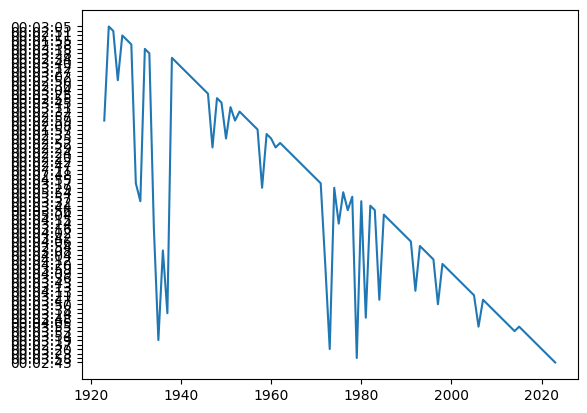

In [24]:
import matplotlib.pyplot as plt

plt.plot(df['year'], df['duration'])

Oops... It seems that the data on the y-axis is not numeric.

Activity Goal:
- List basic information for each column.

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   year      101 non-null    Int64 
 1   artist    101 non-null    string
 2   title     101 non-null    string
 3   duration  101 non-null    string
dtypes: Int64(1), string(3)
memory usage: 3.4 KB


### Parsing the duration
Activity Goals:
- Split the duration values on the ':' character.
- Expand the result into new columns.
- Assign the result to a new dataframe called split_duration.
- Show the first 5 rows of split_duration.

In [27]:
split_duration = df['duration'].str.split(':', expand=True)
split_duration.head(5)

,0,1,2
0,00,02,43
1,00,03,58
2,00,03,23
3,00,03,20
4,00,02,37


Activity Goals:
- Convert all values in split_duration to integers.
- Display the first 5 rows.

In [36]:
split_duration = split_duration.astype('int')
split_duration.head(5)

,0,1,2
0,0,2,43
1,0,3,58
2,0,3,23
3,0,3,20
4,0,2,37


### Naming the Columns

Activity Goals:
- Add 'h', 'm', and 's' columns to our main dataframe.
- Show the first 5 rows.

In [37]:
df[['h', 'm', 's']] = split_duration
df.head(5)

,year,artist,title,duration,h,m,s,total_seconds
0,2023,Morgan Wallen,Last Night,00:02:43,0,2,43,163
1,2022,Glass Animals,Heat Waves,00:03:58,0,3,58,238
2,2021,Dua Lipa,Levitating,00:03:23,0,3,23,203
3,2020,The Weeknd,Blinding Lights,00:03:20,0,3,20,200
4,2019,Lil Nas X feat. Billy Ray Cyrus,Old Town Road,00:02:37,0,2,37,157


### Calculating Total Seconds

Activity Goals:
- Calculate the total seconds for each song.
- Assign the result to a new column called `total_seconds`.
- Display the first 5 rows.

In [30]:
df['total_seconds'] = df.eval('h*3600 + m*60 + s')
df.head(5)


,year,artist,title,duration,h,m,s,total_seconds
0,2023,Morgan Wallen,Last Night,00:02:43,0,2,43,163
1,2022,Glass Animals,Heat Waves,00:03:58,0,3,58,238
2,2021,Dua Lipa,Levitating,00:03:23,0,3,23,203
3,2020,The Weeknd,Blinding Lights,00:03:20,0,3,20,200
4,2019,Lil Nas X feat. Billy Ray Cyrus,Old Town Road,00:02:37,0,2,37,157


# Plotting Top-Hit Song Durations

Activity Goals:
- Plot the total_seconds vs year.
- Label the axes.

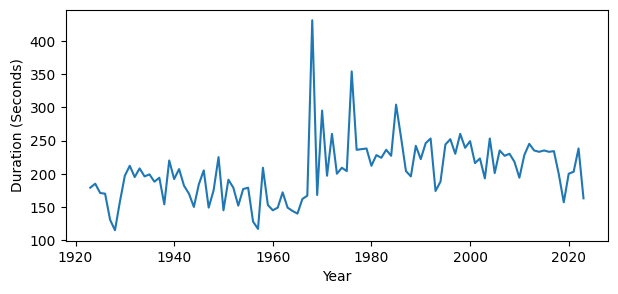

In [38]:
plt.figure(figsize=(7, 3))
plt.plot(df['year'],df['total_seconds'])
plt.xlabel('Year')
plt.ylabel('Duration (Seconds)')
plt.show()


## Project extensions


1. What is the average duration of top songs prior to 1968? After 1968?

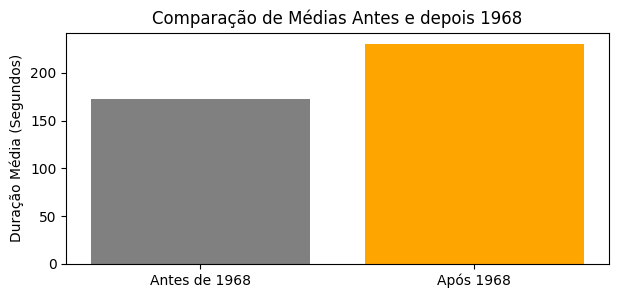

In [47]:
media_antes_1968 = df.query('year < 1968')['total_seconds'].mean()
media_depois = df.query('year >= 1968')['total_seconds'].mean()

plt.figure(figsize=(7, 3))
plt.bar(['Antes de 1968', 'Após 1968'], [media_antes, media_depois], color=['gray', 'orange'])
plt.ylabel('Duração Média (Segundos)')
plt.title('Comparação de Médias Antes e depois 1968')
plt.show()
